https://drive.google.com/file/d/1PW7WGgKDQu4PTKz4A5s-UvVsSF1kgtJM/view?usp=sharing

In [3]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
import re
from nltk.corpus import stopwords
import nltk
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
nltk.download('stopwords', quiet=True)

True

In [6]:
# Initialize Sastrawi stemmer
factory = StemmerFactory()
stemmer = factory.create_stemmer()

In [7]:
# Load the CSV file
df = pd.read_csv('/content/adaKami-reviews.csv')
print("Data shape:", df.shape)
print("Columns:", df.columns.tolist())

Data shape: (2000, 7)
Columns: ['Unnamed: 0', 'date', 'review', 'rating', 'isEdited', 'userName', 'title']


Angka ini menunjukkan dimensi dari dataset Anda, di mana:

2000 adalah jumlah baris (atau rows). Dalam konteks data ini, 2000 kemungkinan besar berarti ada 2.000 ulasan (reviews) yang berbeda.

7 adalah jumlah kolom (atau columns). Ini berarti setiap ulasan memiliki 7 kategori informasi yang berbeda yang tersimpan.

In [8]:
# Data cleaning
df.dropna(subset=['review'], inplace=True)
df.drop_duplicates(subset=['review'], inplace=True)
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df['rating'] = df['rating'].astype(int)
print("After cleaning:", df.shape)

After cleaning: (1979, 7)


After cleaning: (1979, 7)

1979 Baris: Ini adalah jumlah akhir ulasan yang valid dan unik berdasarkan konten ulasan, setelah membuang baris yang isinya hilang atau duplikat.

7 Kolom: Semua variabel ('Unnamed: 0', 'date', 'review', 'rating', 'isEdited', 'userName', 'title') dipertahankan.

In [9]:
# Text preprocessing with stopwords removal and stemming using Sastrawi
def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    stop_words = set(stopwords.words('indonesian'))
    words = text.split()
    words = [word for word in words if word not in stop_words]
    # Apply stemming
    stemmed_words = [stemmer.stem(word) for word in words]
    return ' '.join(stemmed_words)

df['clean_review'] = df['review'].apply(preprocess_text)

1.   Mengubah semua huruf dalam teks ulasan menjadi huruf kecil (lowercase).
2.   Menghapus semua karakter yang bukan huruf (a-z, A-Z) dan bukan spasi (termasuk angka, tanda baca, simbol, dll.). Kemudian, menormalkan spasi ganda menjadi spasi tunggal dan menghapus spasi di awal/akhir (strip).
3. Memecah teks menjadi kata-kata (tokenisasi), lalu membuang kata-kata umum dalam bahasa Indonesia (stopwords seperti 'dan', 'yang', 'adalah', 'saya', 'di', dll.).
4. Mengubah setiap kata menjadi kata dasar atau akar kata menggunakan algoritma Sastrawi (misalnya, 'membersihkan' menjadi 'bersih', 'mendapatkan' menjadi 'dapat').
5. Menerapkan fungsi preprocess_text pada setiap baris di kolom asli 'review' dan menyimpan hasilnya ke kolom baru bernama 'clean_review'.






In [10]:
# TF-IDF
vectorizer = TfidfVectorizer(max_features=1000, min_df=5, max_df=0.8)
tfidf_matrix = vectorizer.fit_transform(df['clean_review'])
print("TF-IDF matrix shape:", tfidf_matrix.shape)

TF-IDF matrix shape: (1979, 794)


1. Jumlah Baris: 1979
Angka ini menunjukkan jumlah dokumen atau ulasan yang di-vektorisasi.

Angka 1979 persis sama dengan jumlah baris (shape) data Anda setelah proses cleaning (pembersihan data), yang mengonfirmasi bahwa semua ulasan yang valid telah berhasil diubah menjadi format numerik.

2. Jumlah Kolom: 794
Angka ini menunjukkan jumlah fitur atau kata unik (terminologi) yang terpilih dan digunakan untuk merepresentasikan seluruh corpus (kumpulan data teks).



In [11]:
# Clustering
num_clusters = 5
kmeans = KMeans(n_clusters=num_clusters, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(tfidf_matrix)

num_clusters = 5: Anda telah memutuskan bahwa data ulasan Anda akan dibagi menjadi 5 kelompok (atau cluster) yang berbeda. Pilihan angka 5 ini mungkin didasarkan pada pengetahuan domain atau hasil dari metode penentuan jumlah cluster optimal (seperti Elbow Method atau Silhouette Score).

random_state=42: Ini digunakan untuk memastikan bahwa hasil inisialisasi cluster (pemilihan titik pusat awal) konsisten setiap kali kode dijalankan. Ini penting untuk reproducibility (keterulangan).

n_init=10: Algoritma K-Means akan dijalankan sebanyak 10 kali dengan inisialisasi titik pusat yang berbeda, dan hasil terbaik (dengan inertia terendah) akan dipilih. Ini membantu menghindari jebakan local minima.

In [25]:
# Analyze clusters
for cluster in range(num_clusters):
    print(f"\nCluster {cluster}:")
    cluster_reviews = df[df['cluster'] == cluster]
    print(f"Number of reviews: {len(cluster_reviews)}")
    print(f"Average rating: {cluster_reviews['rating'].mean():.2f}")
    # Top words
    cluster_tfidf = tfidf_matrix[(df['cluster'] == cluster).to_numpy()]
    mean_tfidf = np.asarray(cluster_tfidf.mean(axis=0)).flatten()
    top_indices = mean_tfidf.argsort()[-10:][::-1]
    top_words = [vectorizer.get_feature_names_out()[i] for i in top_indices]
    print(f"Top words: {', '.join(top_words)}")
    # Sample reviews
    print("Sample reviews:")
    for review in cluster_reviews['review'].head(3).values:
        print(f"- {review[:100]}...")
    print("-" * 50)


Cluster 0:
Number of reviews: 127
Average rating: 2.38
Top words: data, hapus, tolong, pribadi, nama, pinjam, tolak, bapakibu, mohon, tunggu
Sample reviews:
- Nama saya Mayong Jayadi. Per-Tanggal 12 April 2022, saya sudah men-uninstall app ini dan saya tidak ...
- Saya yang bernama supriyoko meminta agar dapat menghapus DATA-DATA saya di aplikasi ini. Dikarenakan...
- Mulai tgl 12/02/2022, saya tidak menggunakan aplikasi ini lagi (adakami)dan uninstall aplikasi adaka...
--------------------------------------------------

Cluster 1:
Number of reviews: 852
Average rating: 1.63
Top words: bunga, nya, adakami, gak, gede, biaya, apk, bayar, iklan, pinjol
Sample reviews:
- Penyebaran Data Pribadi seperti Informasi Elektronik dan Dokumen Elektronik. Serta berisi ancaman ti...
- Bagi yang mau download adakami ini, mending cari yg lain. Jangan adakami, attitude penagihnya kurang...
- Menurut yg saya lihat dr komen lainnya, ada yg positif dan negatif. 90% komen negatif, Sisanya 10% k...
-------

Ringkasan Interpretasi Cluster Ulasan

Cluster 0: Permintaan Penghapusan Data dan Privasi
Kelompok ini didominasi oleh 127 ulasan dengan rata-rata rating 2.38 yang bersentimen agak negatif hingga kecewa. Topik utamanya adalah masalah privasi data. Kata kunci seperti data, hapus, dan pribadi menunjukkan bahwa sebagian besar pengguna dalam cluster ini adalah mereka yang telah berhenti menggunakan layanan (uninstall) dan secara eksplisit meminta agar data pribadi mereka ditarik atau dihapus dari sistem. Mereka menunjukkan kekhawatiran yang serius terhadap bagaimana data mereka dikelola setelah berhenti berlangganan.

Cluster 1: Keluhan Bunga, Biaya, dan Iklan
Ini adalah cluster terbesar dengan 852 ulasan dan rata-rata rating 1.63, menjadikannya salah satu sentimen paling negatif dalam dataset. Ulasan di sini berfokus pada kritik terhadap aspek finansial, ditandai dengan kata kunci seperti bunga, gede (besar), dan biaya. Pengguna menganggap bunga dan biaya layanan terlalu tinggi. Selain itu, cluster ini juga menyinggung penyebaran data pribadi dan sikap penagih yang kurang profesional, menunjukkan kritik menyeluruh terhadap etika bisnis dan transparansi biaya aplikasi.

Cluster 2: Apresiasi Kecepatan Proses dan Kemudahan
Kelompok ini adalah satu-satunya cluster yang bersentimen sangat positif dengan rata-rata rating 4.69 dari 115 ulasan. Topik utama di sini adalah kepuasan terhadap efisiensi layanan, ditunjukkan oleh kata kunci seperti cepat, bantu, cair, dan mudah. Para pengguna ini memuji aplikasi karena proses pengajuan yang cepat dan sederhana, berhasil mendapatkan "nafas buatan" yang mereka butuhkan. Meskipun ada sedikit catatan inkonsistensi waktu proses di beberapa sampel, inti dari cluster ini adalah pengalaman pengguna yang positif dan bernilai tinggi.

Cluster 3: Penolakan Pinjaman dan Klaim Teror Penagihan
Dengan 289 ulasan dan rata-rata rating yang sangat rendah (1.33), cluster ini berfokus pada pengalaman kegagalan proses dan penagihan yang salah sasaran. Kata kunci seperti tolak dan aju menunjukkan ulasan dibuat setelah pengajuan pinjaman ditolak. Masalah yang lebih serius adalah klaim adanya teror penagihan pada pengguna yang sudah lunas atau bahkan tidak pernah memiliki pinjaman (Saya tidak pernah ada pinjaman kok saya di teror). Hal ini menyoroti masalah akut pada akurasi data dan praktik penagihan yang agresif dan tidak berdasar.

Cluster 4: Penagihan Pra-Jatuh Tempo dan Perkataan Kasar
Ini adalah cluster negatif terbesar kedua dengan 596 ulasan dan rata-rata rating terendah, 1.21. Fokus utama cluster ini adalah praktik penagihan yang tidak etis. Kata kunci seperti tagih, tempo, telat, dan jatuh mendefinisikan keluhan spesifik: penagihan dilakukan sebelum tanggal jatuh tempo (3 hari sebelum jatuh Tempo sudah di telpon) dan disertai perkataan kasar (udah dikata2in ga mao bayar). Kelompok ini menuntut perbaikan mendesak pada prosedur dan etika penagihan utang perusahaan.

In [15]:
# Summary
print("Overall Insights:")
print(f"Total reviews: {len(df)}")
print(f"Average rating: {df['rating'].mean():.2f}")
print("Rating distribution:")
print(df['rating'].value_counts().sort_index())

Overall Insights:
Total reviews: 1979
Average rating: 1.69
Rating distribution:
rating
1    1569
2      60
3      32
4      37
5     281
Name: count, dtype: int64


Total Ulasan dan Rata-Rata Rating
Total reviews: 1979

Ini adalah jumlah ulasan yang bersih dan valid setelah proses data cleaning dan pra-pemrosesan teks.

Average rating: 1.69

Rata-rata rating 1.69 berada jauh di bawah nilai tengah (3.0) pada skala 1 hingga 5. Angka ini adalah indikator yang jelas bahwa sentimen keseluruhan dari mayoritas pengguna terhadap aplikasi ini adalah sangat negatif.

Analisis Kritis:

Dominasi Negatif Mutlak: Hampir 80% (tepatnya 79.3%) dari semua ulasan memberikan rating terendah, yaitu bintang 1 (1569 ulasan). Ini menunjukkan bahwa masalah yang dikeluhkan di Cluster 1, 3, dan 4 (Bunga Tinggi dan Penagihan Agresif) adalah isu yang dialami oleh sebagian besar basis pengguna yang meninggalkan ulasan.

Kesenjangan Sentimen: Terdapat kelompok minoritas yang signifikan (281 ulasan atau 14.2%) yang memberikan bintang 5, yang selaras dengan temuan Cluster 2 (Apresiasi Kecepatan). Kesenjangan yang besar antara rating 1 dan 5 mengindikasikan bahwa pengalaman pengguna sangat terpolarisasi: pengguna yang mengalami proses cepat puas, sementara mayoritas sangat kecewa dengan praktik operasional/biaya.

Hampir Tidak Ada Rating Netral: Jumlah rating 2, 3, dan 4 (total 129 ulasan) sangat kecil, menguatkan kesimpulan bahwa sedikit sekali pengguna yang memiliki pengalaman 'biasa-biasa saja'—mereka cenderung sangat mencintai atau sangat membenci layanan ini.


In [16]:
cluster_summary = df.groupby('cluster').agg({
    'rating': ['count', 'mean'],
})
cluster_summary.columns = ['count', 'avg_rating']
print("\nCluster Summary:")
print(cluster_summary)



Cluster Summary:
         count  avg_rating
cluster                   
0          127    2.377953
1          852    1.631455
2          115    4.686957
3          289    1.332180
4          596    1.211409



Analisis Berdasarkan Sentimen (Avg_Rating)

Sentimen Paling Negatif: Klaster 4 memiliki avg_rating terendah (1.21), meskipun Klaster 3 juga sangat rendah (1.33). Kedua klaster ini, yang berfokus pada praktik penagihan yang agresif dan tidak etis, mewakili pengalaman pengguna yang paling buruk.

Sentimen Positif Jelas: Klaster 2 menonjol dengan avg_rating tertinggi (4.69), mengonfirmasi bahwa pengguna sangat menghargai kecepatan dan kemudahan proses yang ditawarkan.

Analisis Berdasarkan Ukuran Klaster (Count)
Isu Skala Besar: Klaster 1 dan 4 secara kumulatif mencakup 1448 ulasan (852+596), yang merupakan 73% dari total ulasan. Hal ini menunjukkan bahwa Biaya Tinggi (Klaster 1) dan Penagihan Pra-Tempo (Klaster 4) adalah masalah terbesar yang dihadapi perusahaan dalam hal volume keluhan.

Kekuatan Aplikasi: Meskipun Klaster 2 memiliki rating tertinggi, ukurannya relatif kecil (115 ulasan), mengindikasikan bahwa sementara pengalaman positif itu ada, pengalaman negatif jauh lebih dominan dan mewakili mayoritas besar pengguna.

/tmp/ipython-input-275125390.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='rating', data=df, palette='viridis', order=sorted(df['rating'].unique()))


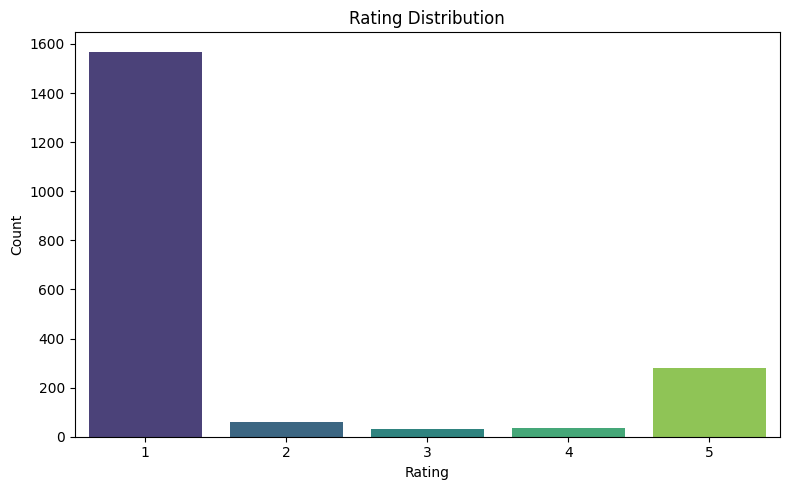

In [18]:
# Visualization: Rating distribution
plt.figure(figsize=(8, 5))
sns.countplot(x='rating', data=df, palette='viridis', order=sorted(df['rating'].unique()))
plt.title('Rating Distribution')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

Interpretasi Visualisasi Distribusi Rating
Visualisasi ini mengonfirmasi bahwa data ulasan Anda memiliki distribusi berbentuk U terbalik (atau sangat timpang), di mana sebagian besar rating terkumpul di kedua ujung spektrum, khususnya pada rating terendah.

1. Dominasi Rating Negatif (Bintang 1)
Bilah tertinggi dalam bagan adalah untuk Rating 1 (bintang 1). Tinggi bilah ini mendekati 1600 ulasan (tepatnya 1569), yang secara visual mengerdilkan bilah lainnya.

Implikasi: Hal ini menunjukkan bahwa hampir 80% dari total ulasan memberikan penilaian yang paling buruk. Secara visual, ini adalah masalah terbesar yang dihadapi oleh aplikasi, mengonfirmasi sentimen negatif yang sangat dominan.

2. Kesenjangan Rating (Bintang 2, 3, dan 4)
Bilah untuk Rating 2, 3, dan 4 hampir tidak terlihat di bagian tengah bagan. Jumlah ulasan di kategori ini sangat kecil (total hanya 129 ulasan).

Implikasi: Ini memvalidasi bahwa pengalaman pengguna sangat terpolarisasi. Hanya sedikit pengguna yang memiliki pengalaman 'netral' atau 'cukup baik'. Mereka cenderung memiliki pengalaman sangat buruk (bintang 1) atau sangat baik (bintang 5).

3. Kekuatan Rating Positif (Bintang 5)
Bilah kedua tertinggi adalah untuk Rating 5 (bintang 5), dengan jumlah 281 ulasan.

Implikasi: Meskipun jauh lebih kecil dari bintang 1, kelompok ini menunjukkan adanya aset kuat dalam aplikasi (yang kita identifikasi sebagai Cluster 2: Kecepatan dan Kemudahan). Kelompok ini penting karena mereka adalah bukti bahwa aplikasi mampu memberikan pengalaman yang sangat memuaskan, meskipun mayoritas pengguna mengalami hal yang sebaliknya.

Kesimpulan Akhir Visual:

Bagan ini adalah representasi visual yang kuat dari kesimpulan strategis: Masalah penagihan dan biaya (Klaster 1, 4, dan 3), yang memicu ulasan Bintang 1, harus menjadi prioritas utama dan mendesak. Mengatasi isu-isu ini adalah satu-satunya cara untuk mengubah bentuk distribusi rating yang saat ini sangat negatif menjadi lebih seimbang.

/tmp/ipython-input-687929936.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='cluster', data=df, palette='muted')


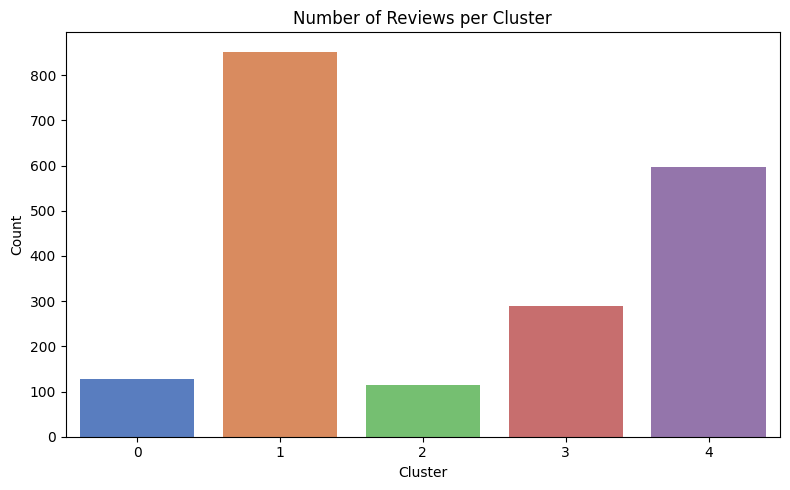

In [19]:
# Visualization: Cluster sizes
plt.figure(figsize=(8, 5))
sns.countplot(x='cluster', data=df, palette='muted')
plt.title('Number of Reviews per Cluster')
plt.xlabel('Cluster')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

Interpretasi Visualisasi Ukuran Klaster
Bagan batang ini menunjukkan bagaimana 1979 ulasan didistribusikan di antara 5 topik utama yang teridentifikasi oleh K-Means.

1. Klaster Keluhan Mayoritas (Isu Skala Besar)
Dua bilah tertinggi merepresentasikan klaster-klaster yang menguasai volume keluhan:

Klaster 1 (Bunga dan Biaya Tinggi): Dengan 852 ulasan, klaster ini adalah yang terbesar dan mendominasi bagan. Hal ini menggarisbawahi bahwa kritik terhadap struktur biaya dan bunga adalah isu utama yang dialami oleh mayoritas pengguna yang meninggalkan ulasan.

Klaster 4 (Penagihan Pra-Tempo/Kasar): Klaster ini adalah yang terbesar kedua dengan 596 ulasan. Ini menunjukkan bahwa masalah praktik penagihan yang agresif dan tidak etis juga merupakan keluhan dengan volume yang sangat tinggi dan tidak dapat diabaikan.

Secara gabungan, 1448 ulasan (73% dari total) berpusat pada masalah biaya/bunga dan praktik penagihan, mengonfirmasi bahwa kedua hal ini adalah prioritas perbaikan tertinggi.

2. Klaster Keluhan Menengah
Klaster 3 (Penolakan dan Klaim Teror Penagihan): Klaster ini berada di posisi ketiga dengan 289 ulasan. Meskipun ukurannya lebih kecil, volume ini masih signifikan dan mengindikasikan masalah serius yang berkelanjutan terkait akurasi penagihan dan proses penolakan pinjaman.

3. Klaster Minoritas
Klaster 0 (Hapus Data/Privasi) dan Klaster 2 (Kepuasan/Kecepatan): Kedua klaster ini memiliki volume yang relatif kecil (127 dan 115 ulasan).

Ukuran kecil Klaster 2 (Kepuasan) menunjukkan bahwa, meskipun aplikasi memiliki keunggulan (kecepatan), pengalaman positif ini belum meluas ke basis pengguna yang lebih besar.

Ukuran kecil Klaster 0 (Permintaan Hapus Data) menunjukkan bahwa isu privasi data, meskipun sensitif, memiliki volume keluhan yang lebih rendah dibandingkan isu operasional/finansial.

Kesimpulan Visual Akhir:

Visualisasi ini secara grafis membenarkan analisis kuantitatif dan kualitatif Anda: Klaster 1 dan 4 adalah masalah volume tinggi yang harus ditangani segera, sementara Klaster 2 menunjukkan area kekuatan yang perlu dipertahankan.

/tmp/ipython-input-2123213162.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cluster_summary.index, y=cluster_summary['avg_rating'], palette='coolwarm')


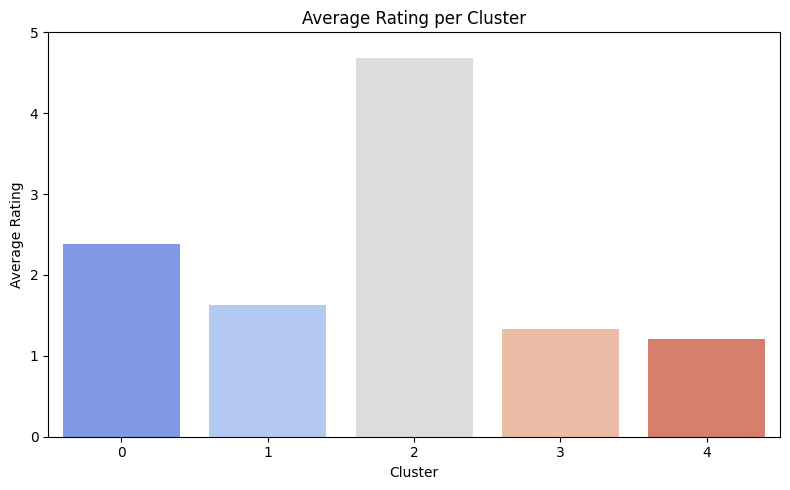

In [20]:
# Visualization: Average rating per cluster
plt.figure(figsize=(8, 5))
sns.barplot(x=cluster_summary.index, y=cluster_summary['avg_rating'], palette='coolwarm')
plt.title('Average Rating per Cluster')
plt.xlabel('Cluster')
plt.ylabel('Average Rating')
plt.ylim(0, 5)
plt.tight_layout()
plt.show()


Interpretasi Visualisasi Rata-Rata Rating per Klaster
Bagan batang ini dengan jelas menunjukkan polaritas ekstrem dalam pengalaman pengguna aplikasi, dengan satu klaster positif menonjol dari empat klaster negatif.

1. Puncak Positif (Kekuatan Aplikasi) 🚀
Klaster 2 memiliki bilah yang sangat tinggi, mendekati 5.0 (tepatnya 4.69).

Implikasi: Ini adalah kekuatan inti aplikasi. Klaster ini, yang berfokus pada kecepatan dan kemudahan proses, berhasil memberikan pengalaman yang sangat memuaskan bagi pengguna yang berhasil. Ketinggian bilah ini menyoroti nilai dari aspek layanan ini.

2. Dasar Negatif (Isu Paling Merusak) 😠
Klaster 4 memiliki bilah terpendek (1.21), diikuti oleh Klaster 3 (1.33) dan Klaster 1 (1.63).

Implikasi: Ketiga klaster ini—yang mewakili penagihan pra-tempo/kasar, penolakan pinjaman/teror penagihan, dan bunga/biaya tinggi—jelas-jelas merupakan sumber utama sentimen negatif dan rating terburuk pada aplikasi. Nilai rating yang mendekati 1.0 menunjukkan tingkat ketidakpuasan yang maksimal.

3. Klaster Netral/Kekecewaan
Klaster 0 memiliki rating yang sedikit lebih tinggi (2.38) dibandingkan klaster negatif lainnya.

Implikasi: Klaster ini, yang berfokus pada permintaan penghapusan data, tidak mewakili kemarahan ekstrem seperti klaster penagihan, melainkan lebih kepada kekecewaan dan keprihatinan etika/privasi setelah interaksi dengan aplikasi.

Kesimpulan Visual Strategis
Grafik ini dengan jelas memvisualisasikan perang sentimen yang terjadi pada ulasan aplikasi Anda. Meskipun Klaster 2 menunjukkan potensi besar untuk keberhasilan, empat klaster negatif lainnya secara kolektif menarik rata-rata keseluruhan (1.69) ke bawah.

Tindakan Prioritas: Fokus strategis harus segera diarahkan untuk mengangkat bilah Klaster 1, 3, dan 4, terutama dengan mengatasi praktik penagihan yang buruk dan tingginya biaya, untuk mencegah basis pengguna yang signifikan terus memberikan rating terendah.

/tmp/ipython-input-2665109595.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_scores, y=top_words, palette='Blues_d')


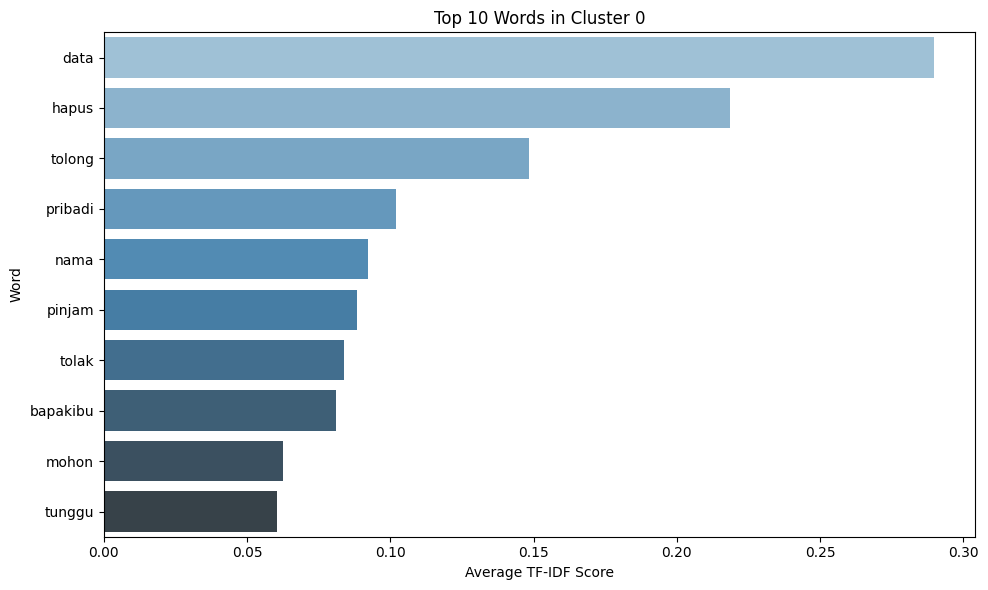

/tmp/ipython-input-2665109595.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_scores, y=top_words, palette='Blues_d')


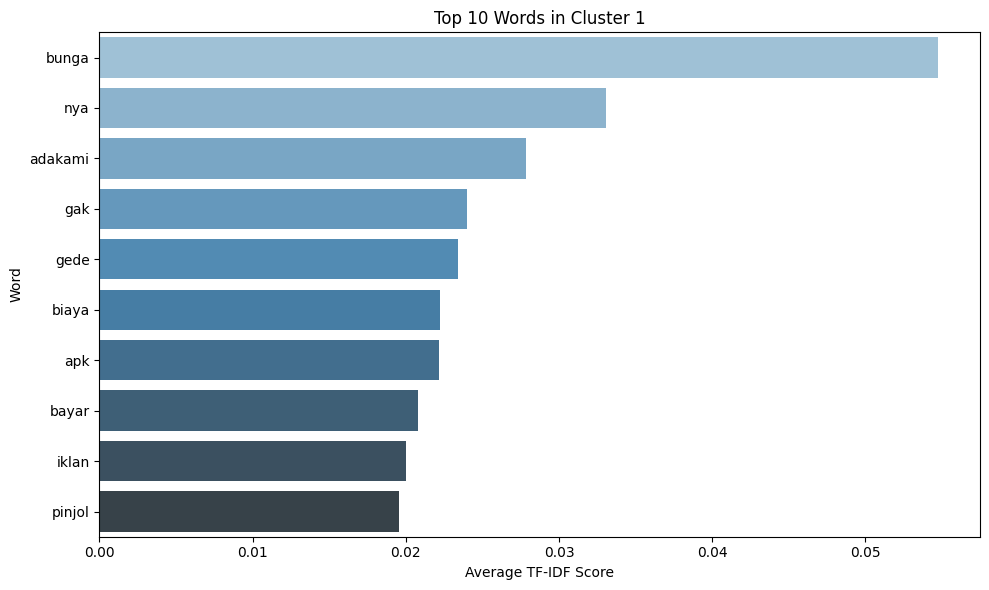

/tmp/ipython-input-2665109595.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_scores, y=top_words, palette='Blues_d')


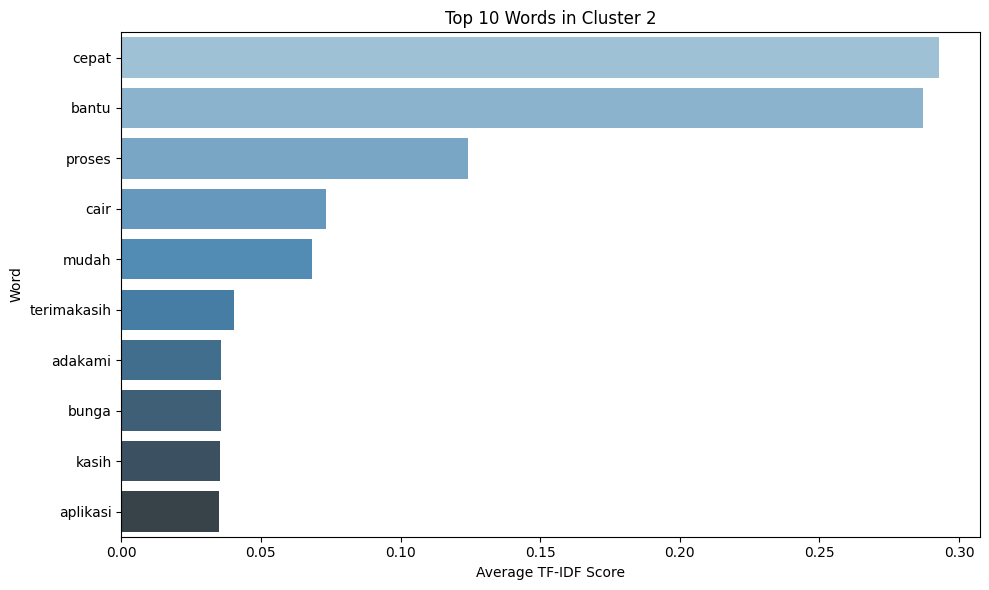

/tmp/ipython-input-2665109595.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_scores, y=top_words, palette='Blues_d')


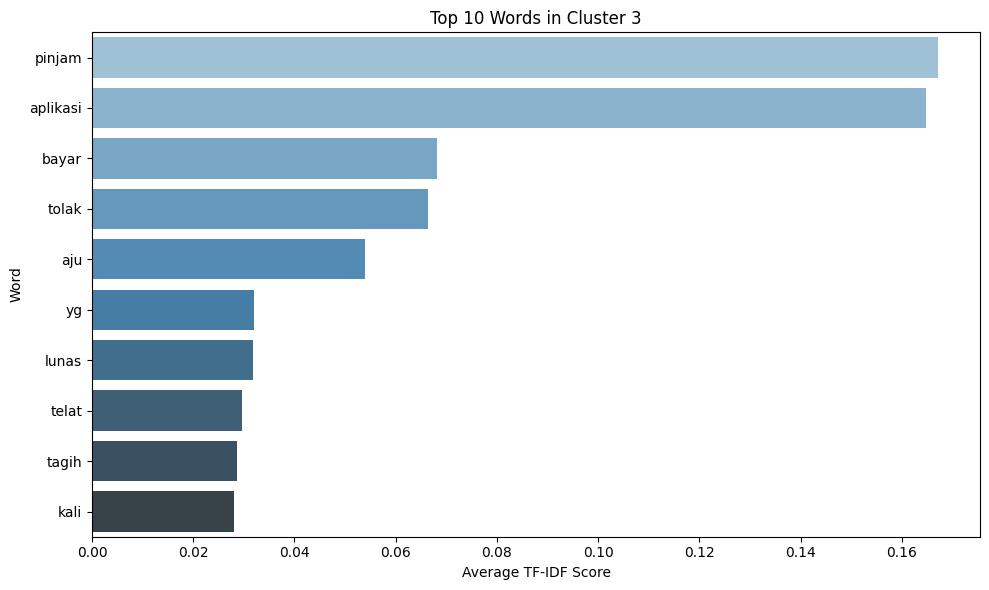

/tmp/ipython-input-2665109595.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_scores, y=top_words, palette='Blues_d')


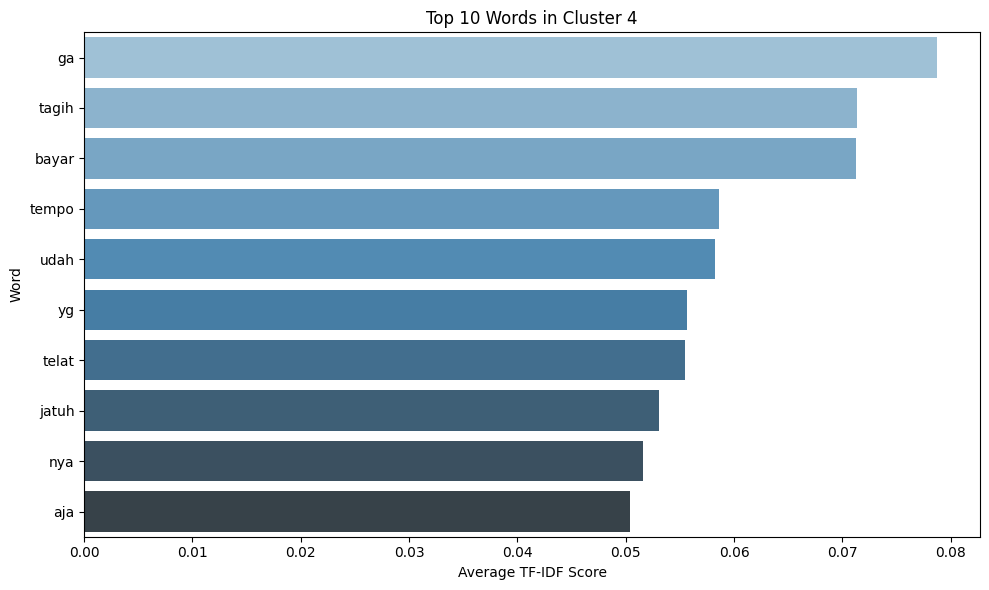

In [24]:
# Visualization: Top words per cluster (bar charts)
top_n = 10
feature_names = vectorizer.get_feature_names_out()

for cluster in range(num_clusters):
    cluster_reviews = df[df['cluster'] == cluster]
    cluster_tfidf = tfidf_matrix[(df['cluster'] == cluster).to_numpy()]
    mean_tfidf = np.asarray(cluster_tfidf.mean(axis=0)).flatten()
    top_indices = mean_tfidf.argsort()[-top_n:][::-1]
    top_words = [feature_names[i] for i in top_indices]
    top_scores = mean_tfidf[top_indices]

    plt.figure(figsize=(10, 6))
    sns.barplot(x=top_scores, y=top_words, palette='Blues_d')
    plt.title(f'Top {top_n} Words in Cluster {cluster}')
    plt.xlabel('Average TF-IDF Score')
    plt.ylabel('Word')
    plt.tight_layout()
    plt.show()

Interpretasi Visualisasi Kata-Kata Teratas per Klaster
Klaster 0: Isu Data dan Privasi
Kata Kunci Dominan: Kata data dan hapus memiliki skor TF-IDF tertinggi secara signifikan.

Interpretasi Visual: Grafik ini dengan jelas menunjukkan bahwa isu utama di sini adalah permintaan penghapusan data. Kata-kata seperti pribadi, nama, pinjam, dan tolak mengonfirmasi bahwa ulasan ini datang dari pengguna yang mengalami penolakan pinjaman atau yang ingin data mereka dihapus setelah berinteraksi dengan layanan pinjaman (pinjam).

Klaster 1: Bunga dan Biaya Tinggi (Klaster Terbesar)
Kata Kunci Dominan: Kata bunga memiliki skor TF-IDF yang jauh lebih tinggi dibandingkan kata lainnya. Diikuti oleh kata-kata seperti nya, adakami, gak, dan gede (besar).

Interpretasi Visual: Visualisasi ini menguatkan kesimpulan bahwa klaster terbesar ini berfokus pada kritik terhadap aspek finansial. Kombinasi bunga dan gede (sering digunakan bersama sebagai 'bunga gede') dan biaya menunjukkan keluhan utama adalah mahalnya layanan. Kata pinjol dan iklan juga menunjukkan kritik terhadap promosi dan identitas aplikasi pinjaman online.

Klaster 2: Kecepatan dan Kemudahan (Klaster Positif)
Kata Kunci Dominan: Kata cepat dan bantu memiliki skor TF-IDF tertinggi dan hampir setara, diikuti oleh proses.

Interpretasi Visual: Grafik ini adalah representasi visual dari kepuasan. Kata cepat dan mudah mendefinisikan kekuatan aplikasi dalam memberikan layanan yang efisien. Kata terimakasih dan kasih semakin memperkuat sentimen positif dan apresiasi terhadap layanan, sementara cair secara spesifik mengacu pada keberhasilan proses pinjaman.

Klaster 3: Penolakan dan Klaim Penagihan Bermasalah
Kata Kunci Dominan: Kata pinjam dan aplikasi memiliki skor tertinggi, diikuti oleh kata-kata yang terkait dengan proses gagal: tolak dan aju (mengajukan).

Interpretasi Visual: Klaster ini secara visual jelas membagi fokusnya antara proses pinjaman dan dampak setelahnya. Tingginya bobot tolak dan aju mengindikasikan frustrasi karena permohonan sering ditolak. Kehadiran lunas dan tagih di bagian bawah grafik juga menunjukkan adanya masalah penagihan yang tidak tepat sasaran pada pengguna yang sudah menyelesaikan kewajibannya.

Klaster 4: Penagihan Pra-Tempo dan Konflik (Sentimen Terburuk)
Kata Kunci Dominan: Kata ga (tidak), tagih, dan bayar mendominasi bagian atas grafik. Diikuti oleh kata-kata yang terkait waktu: tempo dan telat (jatuh tempo, telat bayar).

Interpretasi Visual: Grafik ini memberikan bukti visual paling kuat mengenai masalah penagihan yang agresif dan prematur. Urutan kata ga (tidak), tagih, bayar dan tempo mencerminkan konteks: "belum jatuh tempo tapi sudah di-tagih" atau "dikatain ga mau bayar". Klaster ini, dengan rating rata-rata terendah (1.21), jelas-jelas didorong oleh isu etika penagihan dan waktu penagihan yang tidak tepat.

